# 03 · SINDy-PI (Parallel / Implicit)

Michaelis–Menten enzyme kinetics deplete substrate $S$ at a **saturating, rational** rate.
For the mechanism with rate constants $k=k_r=k_{cat}=1$ and total enzyme $E_0=1$ (the exact
system we discover as a DAE in notebook `04`), the quasi-steady-state substrate law is

$$\frac{dS}{dt} = -\,\frac{V_{\max}\,S}{K_m + S},
\qquad V_{\max}=k_{cat}E_0 = 1,\quad K_m=\frac{k_r+k_{cat}}{k}=2 .$$

A **polynomial** library can never represent $S/(K_m+S)$ exactly. **SINDy-PI** rewrites the
search in **implicit** form so the unknown may appear on both sides,

$$(K_m+S)\,\dot S = -V_{\max}\,S
\;\;\Longleftrightarrow\;\;
\underbrace{K_m\,\dot S + S\,\dot S}_{\text{implicit terms}} + V_{\max}\,S = 0,$$

and sparsely regresses each candidate term (now including products with $\dot S$) against the
others. We use `pysindy`'s `PDELibrary(implicit_terms=True)` + the `cvxpy`-backed `SINDyPI`
optimizer.

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

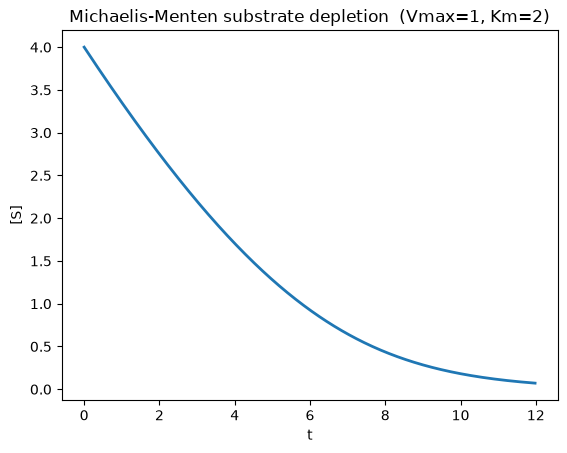

In [3]:
from sparse_demos import systems
import pysindy as ps

# Substrate depletion data. Vmax=1, Km=2 -- identical to the MM system in notebook 04,
# so the rational law we recover here is exactly the reduced form of that DAE.
t, X = systems.simulate_mm(t_span=(0, 12), dt=0.02, s0=4.0, vmax=1.0, km=2.0)
S = X[:, :1]                      # substrate column, shape (n, 1)
dt = t[1] - t[0]
plt.plot(t, S, lw=2); plt.xlabel("t"); plt.ylabel("[S]")
plt.title("Michaelis-Menten substrate depletion  (Vmax=1, Km=2)"); plt.show()

## Why a polynomial library is the *wrong model*

Vanilla SINDy can only fit a polynomial. It will return a few terms that approximate the
rational curve **on the training range**, but the functional form is wrong — and that shows up
immediately if we evaluate the discovered rate outside the data.

Vanilla SINDy (polynomial) model:
(S)' = -0.011 1 + -0.421 S +  0.111 S^2 + -0.012 S^3


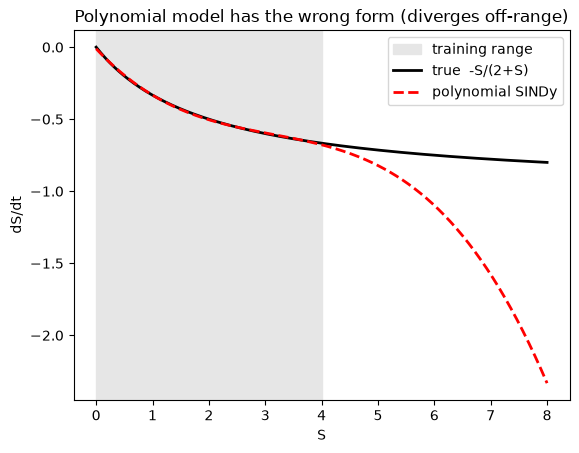

In [4]:
poly = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3),
                optimizer=ps.STLSQ(threshold=0.01))
poly.fit(S, t=dt, feature_names=["S"])
print("Vanilla SINDy (polynomial) model:")
poly.print()

# Compare the discovered rate to the truth, including beyond the training range.
S_grid = np.linspace(0, 8, 300).reshape(-1, 1)
true_rate = -1.0 * S_grid[:, 0] / (2.0 + S_grid[:, 0])
poly_rate = poly.predict(S_grid)[:, 0]
plt.axvspan(0, 4, color="0.9", label="training range")
plt.plot(S_grid, true_rate, "k", lw=2, label="true  -S/(2+S)")
plt.plot(S_grid, poly_rate, "r--", lw=2, label="polynomial SINDy")
plt.xlabel("S"); plt.ylabel("dS/dt"); plt.legend()
plt.title("Polynomial model has the wrong form (diverges off-range)"); plt.show()

## SINDy-PI recovers the implicit rational law

We give SINDy-PI an implicit library (low-order monomials **times** $\dot S$). It returns one
sparse implicit equation per candidate left-hand side; read the **`(S) = ...`** row.

In [5]:
pde_lib = ps.PDELibrary(
    function_library=ps.PolynomialLibrary(degree=1, include_bias=False),
    derivative_order=1, temporal_grid=t,
    implicit_terms=True, include_bias=True,
)
# model_subset=[1,2,3] skips fitting the constant "1" as a left-hand side (index 0),
# whose implicit equation is degenerate and just clutters the output.
opt = ps.SINDyPI(reg_weight_lam=1e-4, regularizer="l1", tol=1e-12, max_iter=30000,
                 normalize_columns=False, model_subset=[1, 2, 3])
pi = ps.SINDy(feature_library=pde_lib, optimizer=opt)
pi.fit(S, t=dt, feature_names=["S"])

print("Implicit library terms:", pi.get_feature_names())
print("\nSINDy-PI implicit equations:")
pi.print(precision=3)

Model  1


Model  2
Model  3


Implicit library terms: ['1', 'S', 'S_t', 'SS_t']

SINDy-PI implicit equations:
(1) =  0.000
(S) = -2.000 S_t + -1.000 SS_t
(S_t) = -0.500 S + -0.500 SS_t
(SS_t) = -1.000 S + -2.000 S_t


The **`(S)`** row reads

$$S = -2.0\,\dot S \;-\; 1.0\,(S\,\dot S)
\;\;\Longleftrightarrow\;\;
(2 + S)\,\dot S = -S
\;\;\Longleftrightarrow\;\;
\boxed{\;\dot S = -\dfrac{S}{2 + S}\;}$$

i.e. $(K_m+S)\dot S = -V_{\max}S$ with $K_m=2,\ V_{\max}=1$ — the exact rational law.

> **A note on richer libraries / model selection.** If you raise the implicit library to
> degree 2+, SINDy-PI also returns *redundant* relations such as the `(S^2)` row, which is
> simply $S \times$ the `(S)` row. They encode the same physics, so practical SINDy-PI pairs
> the fit with a model-selection / common-factor-cancellation step that keeps the lowest-degree
> (fundamental) relation. Here we used a focused degree-1 implicit library so the fundamental
> law comes out directly.

**Takeaway.** SINDy-PI handles rational/implicit dynamics that defeat polynomial SINDy. But it
treated $S$ as a lone variable with a hand-built implicit library. When the system genuinely
*has* hidden algebraic structure (conservation laws, quasi-steady state), we want a method that
discovers that structure itself — and recovers this very rational law as a consequence.
→ `04_sodas_dae.ipynb`